<a href="https://colab.research.google.com/github/SebMun33/AA1-TUIA-Munoz-Onyskiw-Calenta/blob/main/TP_AA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importamos las librerias

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


##Cargamos el dataframe🛢

In [ ]:
df = pd.read_csv('weatherAUS_2026C1.csv')

##Ver si las columnas tienen nombres coherentes y si los datos parecen estar en su lugar

In [ ]:
df.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


Aqui veremos cuántas entradas hay y si las columnas son float64, int64 o object

In [ ]:
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
df.info()

El dataset tiene 134055 filas y 25 columnas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134055 entries, 0 to 134054
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        134055 non-null  int64  
 1   Date              134054 non-null  object 
 2   Location          134054 non-null  object 
 3   MinTemp           132659 non-null  float64
 4   MaxTemp           132851 non-null  float64
 5   Rainfall          130887 non-null  float64
 6   Evaporation       75210 non-null   float64
 7   Sunshine          69907 non-null   float64
 8   WindGustDir       123937 non-null  object 
 9   WindGustSpeed     123996 non-null  float64
 10  WindDir9am        124170 non-null  object 
 11  WindDir3pm        129916 non-null  object 
 12  WindSpeed9am      132332 non-null  float64
 13  WindSpeed3pm      131038 non-null  float64
 14  Humidity9am       131504 non-null  float64
 15  Humidity3pm       13040

##Eliminamos la columna Unnamed: 0 ya q notamos q es un indice redundante q no aporta informacion climatica

In [ ]:
# Eliminamos la columna indicando axis=1 e inplace=True para aplicar el cambio al df original
df.drop('Unnamed: 0', axis=1, inplace=True)

df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'RainfallTomorrow'],
      dtype='object')

##Aqui transformamos la columna Date  de tipo Object a datetime, ya q es importante identificar correctamente los tipos de variables, con el objetivo de habilitar la capacidad de analizar los datos

In [ ]:
# Convertimos a formato fecha
df['Date'] = pd.to_datetime(df['Date'])

print(f"Nuevo tipo de dato de Date: {df['Date'].dtype}")

Nuevo tipo de dato de Date: datetime64[ns]


##Convertimos las columnas de texto a minusculas y eliminamos espacios en blanco para poder evitar duplicacion de categoria por errores de tipeo

In [ ]:
#seleccionamos columnas tipo objeto
cols_texto = df.select_dtypes(include=['object']).columns

for col in cols_texto:
    df[col] = df[col].str.lower().str.strip()

df['Location'].unique()
#verificamos algunas categorias


array(['albury', 'badgeryscreek', 'cobar', 'coffsharbour', 'moree',
       'newcastle', 'norahhead', 'norfolkisland', 'penrith', 'richmond',
       'sydney', 'sydneyairport', 'waggawagga', 'williamtown',
       'wollongong', 'canberra', 'tuggeranong', 'mountginini', 'ballarat',
       'bendigo', 'sale', 'melbourneairport', 'melbourne', 'mildura',
       'nhil', 'portland', 'watsonia', 'dartmoor', 'brisbane', 'cairns',
       'goldcoast', 'townsville', 'adelaide', 'mountgambier', 'nuriootpa',
       'woomera', 'albany', 'witchcliffe', 'pearceraaf', 'perthairport',
       'perth', 'salmongums', 'walpole', 'hobart', 'launceston', nan],
      dtype=object)

##Ahora calcularemos el porcentaje de datos nulos por cada columna, ya q si hay muchos podria ser no coanfiable. Al identificarlas no ayudara a elegir entre eliminar filas o completar los datos

In [ ]:
# Sumamos los nulos y calculamos su porcentaje sobre el total de filas
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df)) * 100

# creamos una tabla para verlo mejor
tabla_nulos = pd.DataFrame({'Nulos Totales': nulos, 'Porcentaje (%)': nulos_pct})
print(tabla_nulos.sort_values(by='Porcentaje (%)', ascending=False))

                  Nulos Totales  Porcentaje (%)
Sunshine                  64148       47.852001
Evaporation               58845       43.896162
Cloud3pm                  55856       41.666480
Cloud9am                  53017       39.548693
Pressure9am               13897       10.366641
Pressure3pm               13860       10.339040
WindGustDir               10118        7.547648
WindGustSpeed             10059        7.503637
WindDir9am                 9885        7.373839
WindDir3pm                 4139        3.087539
Humidity3pm                3655        2.726493
RainToday                  3168        2.363209
Rainfall                   3168        2.363209
RainfallTomorrow           3166        2.361717
RainTomorrow               3166        2.361717
WindSpeed3pm               3017        2.250569
Temp3pm                    2872        2.142404
Humidity9am                2551        1.902950
WindSpeed9am               1723        1.285293
Temp9am                    1707        1

##Aqui eliminaremos las filas donde la columna RainTomorrow sean nulas. Esto para a futuro poder predecir si llovera mañana, los registros q no tienen ese dato no serven para entrenar un modelo

In [ ]:
#eliminamos registros con datos nulos solo en la columna objetivo
df.dropna(subset=['RainTomorrow'], inplace=True)

print(f"registro finales despues de la limpieza: {df.shape[0]}")

registro finales despues de la limpieza: 130889


##Se crea una nueva columna llamada month a partir de la columna Date par poder revelar pratones ocultos en el clima, el mes es una variable mucho mas explicativa q la fecha exacta

In [ ]:
#al ya haber convertido Date a datetime antes podemos extraer el mes facilmente
df['Month'] = df['Date'].dt.month

#comprobamos la creacion de la nueva variable
df[['Date', 'Month']].head()


,Date,Month
0,2008-12-01,12
1,2008-12-02,12
2,2008-12-03,12
3,2008-12-04,12
4,2008-12-05,12


##📊 En esta celda generamos un grafico de barras para ver las columnas mas complicadas, esto para poder ver si las variables  Rainfal o Maxtemp estan muy afectadas

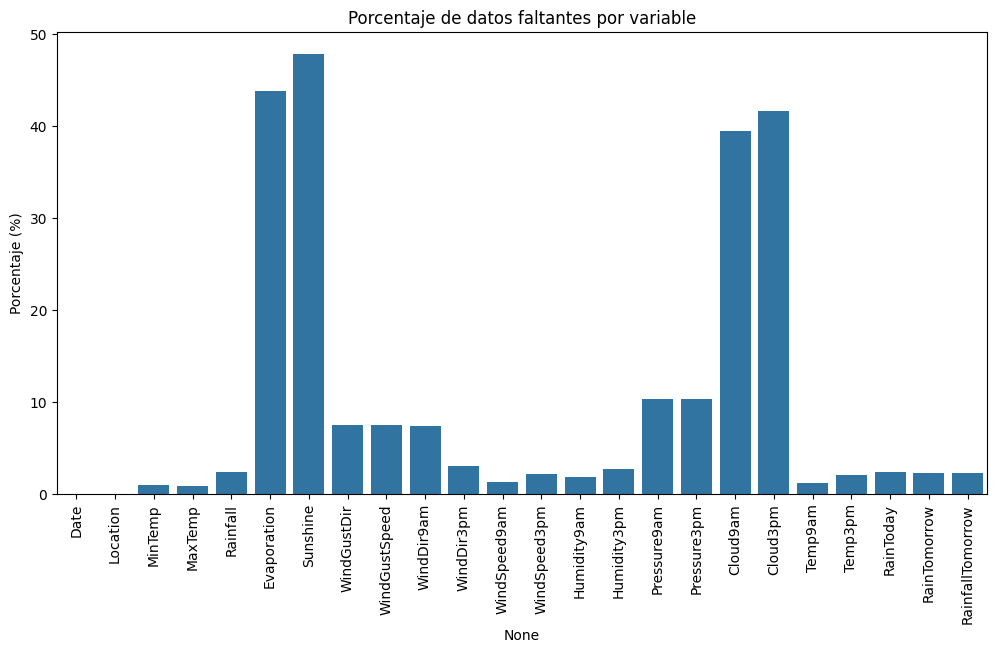

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=tabla_nulos.index, y=tabla_nulos['Porcentaje (%)'])
plt.xticks(rotation=90)
plt.title('Porcentaje de datos faltantes por variable')
plt.show()

## 📊 lo q vemos es q las variables Evaporation Y Sushine tienen una falta de datos mayor de 35%. Debido a este porcentaje tan alto la imputacion simple puede ser arriesgada, para esta EDA inicial mantendre las columnas pero tendre precaucion al sacar conclusiones de estas. Mientras q para variables menor al 5% optaremos por la imputacion simple

##Ahora crearemos un diagrama de caja (boxplot) para la variable MaxTemp, ya q nos permite indentificar visualmente la mediana, los cuartiles y los valores q se alejan del resto (puntos fuera de lo bigotes).Y luego determinar si existen registros climaticos extremos q puedan ser errores de sensor o evento climaticos muy inusuales

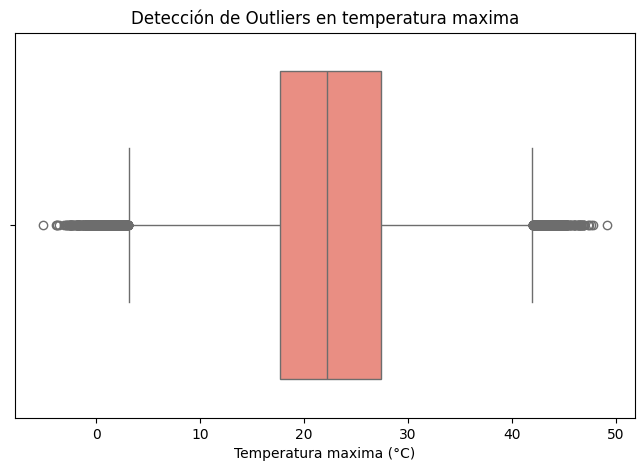

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['MaxTemp'], color='salmon')
plt.title('Detección de Outliers en temperatura maxima')
plt.xlabel('Temperatura maxima (°C)')
plt.show()

##🌡️Lo q podemos ver es q la linea central dentro de la caja es la mediana. Los puntos q aparecen a la derecha 'si es q lo hay' son los outliers. Con esto podemos concluir q si vemos temp de 50 grados podrian ser reales en las partes de Australia mas deserticas pero de ser el caso de ver 100 grados seria un error de carga. Dada la situacion mantendremos esos datos

##Luego de esto vamos a realizar el analisis brivariante usando la matriz de correlacion ya q sirve para ver la relacion entre variable entre si. Para esto calcularemos e imprimimos un mapa de calor de la correlaciones entre las variables numericas, haremos esto pq las variables altamente correlacionadas dan informacion similar, al identificarlas ayudara a entender la estructura del dataset para evitar redundancias. Esto lo haremos con el objetivo de si hay factores climaticos q se muevan juntos

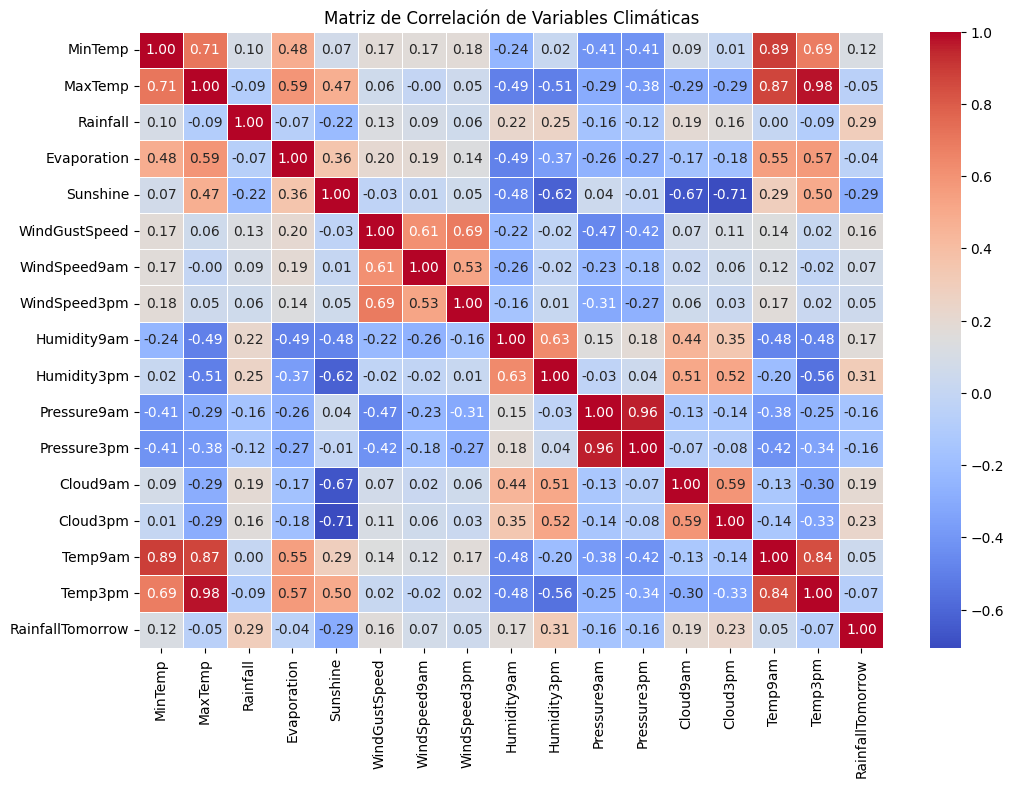

In [ ]:
#seleccionamos solo las columnas con numeros para poder calcular la correlacion
corr = df.select_dtypes(include=['float64', 'int64']).corr()

#configuramos el tamaño del grafico
plt.figure(figsize=(12, 8))

# Creamos el mapa de calor
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación de Variables Climáticas')
plt.show()